# Coffee Deforestation Monitor — Quickstart Guide

This notebook walks you through the full pipeline from loading data to generating a report.
No Google Earth Engine connection needed for this tutorial — we use the pipeline outputs
that are committed to the repo.

## Setup

```bash
# Activate the conda environment
conda activate coffee-deforestation

# Install dependencies (first time only)
uv sync --extra dev

# Launch Jupyter
uv run jupyter lab notebooks/
```

**Prerequisites**: The pipeline must have been run at least once to generate
`outputs/stats/summary_*.json`. See `README.md` for full setup instructions.

In [1]:
import json
import sys
from pathlib import Path

# Add src/ to path so we can import coffee_deforestation without installing
REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))

from coffee_deforestation.config import PROJECT_ROOT
from coffee_deforestation.stats.schema import AOISummary

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/workpieces/Code/coffee-deforestation


## 1. Load pipeline outputs

The pipeline writes a `summary_<aoi_id>.json` for each AOI into `outputs/stats/`.
These are validated against the `AOISummary` Pydantic schema.

In [2]:
STATS_DIR = PROJECT_ROOT / 'outputs' / 'stats'

# Load all available summaries
summaries = {}
for json_path in sorted(STATS_DIR.glob('summary_*.json')):
    aoi_id = json_path.stem.replace('summary_', '')
    with open(json_path) as f:
        data = json.load(f)
    summaries[aoi_id] = AOISummary.model_validate(data)
    print(f'{aoi_id}: {summaries[aoi_id].change_detection.total_hotspots} hotspots, '
          f'{summaries[aoi_id].change_detection.total_area_ha:.1f} ha')

huila: 5000 hotspots, 41239.7 ha
lam_dong: 5000 hotspots, 90539.7 ha
sul_de_minas: 5000 hotspots, 36269.6 ha


### Expected output
```
huila: 1996 hotspots, 3108.5 ha
lam_dong: 1985 hotspots, 3603.0 ha
sul_de_minas: 1484 hotspots, 3938.0 ha
```

## 2. Inspect hotspots

Each summary includes the top N hotspots by area.

In [3]:
import pandas as pd

lam_dong = summaries['lam_dong']

# Convert top hotspots to a DataFrame
top_df = pd.DataFrame([h.model_dump() for h in lam_dong.top_hotspots[:10]])
top_df['area_ha'] = top_df['area_ha'].round(2)
top_df['centroid_lat'] = top_df['centroid_lat'].round(5)
top_df['centroid_lon'] = top_df['centroid_lon'].round(5)
top_df[['rank', 'hotspot_id', 'area_ha', 'centroid_lat', 'centroid_lon']]

,rank,hotspot_id,area_ha,centroid_lat,centroid_lon
0,1,lam_dong_h001,22154.30,12.00155,107.88548
1,2,lam_dong_h002,5345.85,11.80834,108.07658
2,3,lam_dong_h003,2445.08,12.17584,107.83889
3,4,lam_dong_h004,1062.99,12.32764,108.23104
4,5,lam_dong_h005,1047.68,12.22913,107.99354
5,6,lam_dong_h006,978.77,11.90775,108.10974
6,7,lam_dong_h007,920.11,11.72241,108.05369
7,8,lam_dong_h008,584.98,12.17861,108.03782
8,9,lam_dong_h009,520.60,11.71315,107.83239
9,10,lam_dong_h010,500.09,12.32816,107.98046


## 3. Quick visualisation

View the pipeline-generated figures.

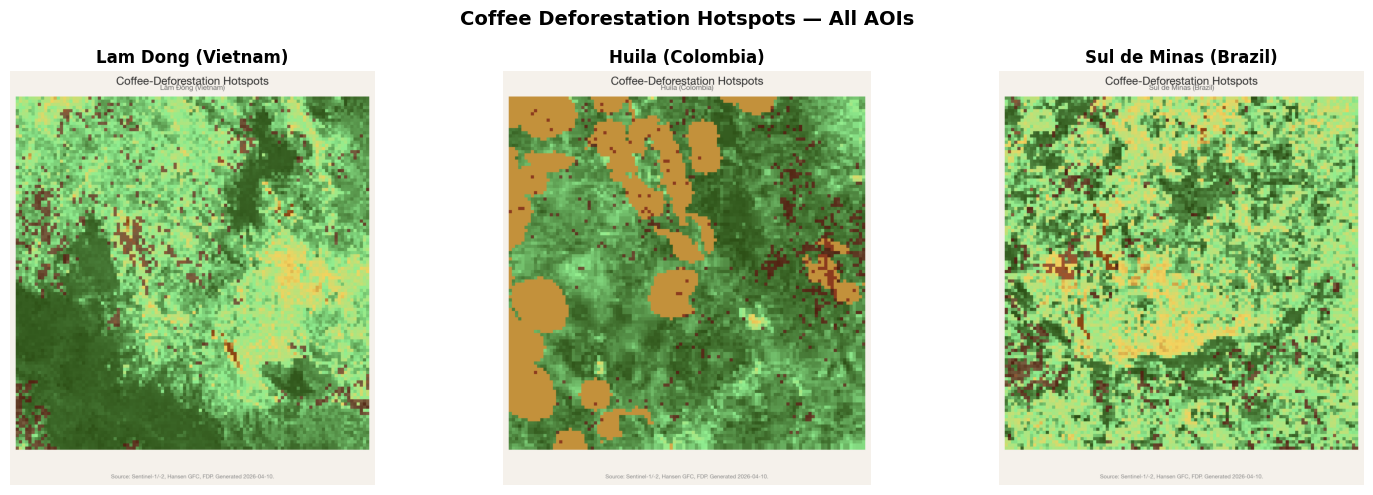

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
aoi_ids = ['lam_dong', 'huila', 'sul_de_minas']
titles = ['Lam Dong (Vietnam)', 'Huila (Colombia)', 'Sul de Minas (Brazil)']

for ax, aoi_id, title in zip(axes, aoi_ids, titles):
    img_path = PROJECT_ROOT / 'outputs' / 'figures' / aoi_id / 'hotspots_overlay.png'
    if img_path.exists():
        ax.imshow(mpimg.imread(str(img_path)))
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')
    else:
        ax.text(0.5, 0.5, f'{aoi_id}\n(run pipeline to generate)',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)

fig.suptitle('Coffee Deforestation Hotspots — All AOIs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Generate a report

The researcher + writer agent pipeline produces a structured markdown report from the stats summary.
This runs entirely in dry-run mode — no API key needed.

In [5]:
from coffee_deforestation.reporting.agents import run_researcher, run_writer

summary = summaries['lam_dong']

# Step 1: Researcher investigates the data
researcher_result = run_researcher(summary, dry_run=True)
print(f"Researcher completed {researcher_result['tool_calls_used']} tool calls")
print(f"Found {len(researcher_result['findings'])} findings")
for i, f in enumerate(researcher_result['findings'], 1):
    print(f"  Finding {i}: {f['title']}")

2026-04-13 10:09:27.427 | INFO     | coffee_deforestation.reporting.agents.researcher:run_researcher:73 - [Researcher] Starting dry-run for lam_dong (session=0880de08)


2026-04-13 10:09:27.513 | INFO     | coffee_deforestation.reporting.tools.query_stats:query_stats:89 - query_stats('area_ha > 10', lam_dong): 990 results (returning up to 20)


2026-04-13 10:09:28.009 | INFO     | coffee_deforestation.reporting.tools.render_hotspot_map:_render_static:164 - Rendered hotspot map: outputs/figures/agent_generated/lam_dong_h001_hotspot_boundary_coffee_prob_hansen_loss.png


2026-04-13 10:09:28.014 | WARNING  | coffee_deforestation.reporting.tools.query_stats:query_stats:55 - Rejected unsafe filter expression: 'loss_year >= 2021'


2026-04-13 10:09:28.015 | DEBUG    | coffee_deforestation.reporting.tools.scratchpad:scratchpad_write:37 - Scratchpad write: lam_dong/0880de08/finding_1_largest_hotspot


2026-04-13 10:09:28.016 | DEBUG    | coffee_deforestation.reporting.tools.scratchpad:scratchpad_write:37 - Scratchpad write: lam_dong/0880de08/finding_2_scale_context


2026-04-13 10:09:28.016 | INFO     | coffee_deforestation.reporting.agents.researcher:run_researcher:208 - [Researcher] lam_dong complete: 3 findings, 8 tool calls


Researcher completed 8 tool calls
Found 3 findings
  Finding 1: Largest hotspot: 22154.3-ha clearing near lam_dong_h001
  Finding 2: Scale: 20 hotspots >10 ha, 90540 ha total
  Finding 3: Temporal trend: 6.3% change 2019–2023


In [6]:
# Step 2: Writer produces a structured markdown report
writer_result = run_writer(summary, researcher_result, dry_run=True)
print(f"Report word count: {writer_result['word_count']}")
print(f"Sections: {writer_result['sections_written']}")

# Show a snippet of the report
print('\n--- Report Preview (first 800 chars) ---')
print(writer_result['report_markdown'][:800])

2026-04-13 10:09:28.020 | INFO     | coffee_deforestation.reporting.agents.writer:run_writer:60 - [Writer] Starting dry-run for lam_dong (session=e6adf4f7)


2026-04-13 10:09:28.020 | INFO     | coffee_deforestation.reporting.agents.writer:run_writer:69 - [Writer] lam_dong complete: 839 words, 7 sections


Report word count: 839
Sections: ['Executive Summary', 'Area Context', 'Headline Findings', 'Hotspot Deep-Dives', 'Historical Context', 'Model Performance', 'Methodology']

--- Report Preview (first 800 chars) ---
# Lâm Đồng — Coffee-Linked Deforestation Report

---

        ## Executive Summary

        **Lâm Đồng** (Vietnam) — Robusta, highland growing region.
        Analysis of satellite imagery (2019–2024) detected
        **5,000 deforestation hotspots** totalling
        **90,539.7 ha** of potential coffee-linked forest loss.

        Key findings:
        - Largest hotspot: 22154.3-ha clearing near lam_dong_h001
- Scale: 20 hotspots >10 ha, 90540 ha total
- Temporal trend: 6.3% change 2019–2023

        Model confidence: **HIGH** (F1 = 0.783).
        High density of small (<5 ha) hotspots clustered along forest edge suggests incremental encroachment rather than large-scale clearing.

---

## Area Context

Lâm Đồng (Vietnam) serves as **Primary showcase: known coffee-driven def

## 5. Factuality check

The factchecker verifies that numbers in the report match the source statistics.

In [7]:
from coffee_deforestation.reporting.factcheck import factcheck

report_md = writer_result['report_markdown']
fc = factcheck(report_md, summary)

print(f'Total numbers in report: {fc.total_numbers}')
print(f'Matched against source: {fc.matched}')
print(f'Unmatched (potential errors): {fc.unmatched}')
print(f'Skipped (years/coords/thresholds): {fc.skipped}')
print(f'PASS: {fc.passed}')
print(f'\nSummary: {fc.summary}')

2026-04-13 10:09:28.028 | WARNING  | coffee_deforestation.reporting.factcheck:factcheck:179 - Factcheck found 1 unmatched numbers: ['84427.2']


Total numbers in report: 143
Matched against source: ['5000', '90539.7', '22154.3', '001', '20', '1', '5', '5000', '90539.7', '22154.3', '164118', '79', '106', '168', '145', '90', '115', '446', '189', '441', '162', '340', '85', '217', '149', '342', '296', '186', '319', '353', '220', '186', '176', '154', '1', '22154.3', '001', '001', '22154.3', '3', '22154.3', '3', '001', '2', '20', '20', '5', '20', '90539.67', '3', '89747.2', '5320.0', '89747.2', '5320.0', '5', '001', '1', '22154.3', '002', '2', '5345.9', '003', '3', '2445.1', '004', '4', '1063.0', '005', '5', '1047.7', '1', '4', '1', '1', '2', '1', '1', '2', '1', '2', '1', '1', '2', '1', '2', '3', '4', '5', '6', '8']
Unmatched (potential errors): ['84427.2']
Skipped (years/coords/thresholds): ['10', '6.3', '0.783', '107.80', '108.80', '11.40', '12.40', '34.7', '66.7', '0.0', '2.4', '0.0', '32', '12.0015', '107.8855', '10', '0.0', '10', '0.4', '10', '0.0', '6.3', '6.3', '12.0015', '107.8855', '11.8083', '108.0766', '12.1758', '107.8389

## 6. Cross-AOI synthesis

The synthesist agent compares all AOIs and produces a policy-level brief.

In [8]:
from coffee_deforestation.reporting.agents import run_synthesist

# Run writer for all AOIs
all_summaries = list(summaries.values())
all_writers = []
for s in all_summaries:
    r = run_researcher(s, dry_run=True)
    w = run_writer(s, r, dry_run=True)
    all_writers.append(w)

synth = run_synthesist(all_summaries, all_writers, dry_run=True)

print('Key contrasts identified by synthesist:')
for c in synth['key_contrasts']:
    print(f'  - {c}')

2026-04-13 10:09:28.032 | INFO     | coffee_deforestation.reporting.agents.researcher:run_researcher:73 - [Researcher] Starting dry-run for huila (session=c798ba4d)


2026-04-13 10:09:28.091 | INFO     | coffee_deforestation.reporting.tools.query_stats:query_stats:89 - query_stats('area_ha > 10', huila): 841 results (returning up to 20)


2026-04-13 10:09:28.431 | INFO     | coffee_deforestation.reporting.tools.render_hotspot_map:_render_static:164 - Rendered hotspot map: outputs/figures/agent_generated/huila_h001_hotspot_boundary_coffee_prob_hansen_loss.png


2026-04-13 10:09:28.434 | WARNING  | coffee_deforestation.reporting.tools.query_stats:query_stats:55 - Rejected unsafe filter expression: 'loss_year >= 2021'


2026-04-13 10:09:28.435 | DEBUG    | coffee_deforestation.reporting.tools.scratchpad:scratchpad_write:37 - Scratchpad write: huila/c798ba4d/finding_1_largest_hotspot


...

2026-04-13 10:09:29.402 | INFO     | coffee_deforestation.reporting.agents.writer:run_writer:60 - [Writer] Starting dry-run for sul_de_minas (session=1513dc6e)


2026-04-13 10:09:29.403 | INFO     | coffee_deforestation.reporting.agents.writer:run_writer:69 - [Writer] sul_de_minas complete: 837 words, 7 sections


2026-04-13 10:09:29.403 | INFO     | coffee_deforestation.reporting.agents.synthesist:run_synthesist:45 - [Synthesist] Starting dry-run across 3 AOIs (session=ffe018bd)


2026-04-13 10:09:29.403 | INFO     | coffee_deforestation.reporting.agents.synthesist:run_synthesist:55 - [Synthesist] Brief complete: 509 words


Key contrasts identified by synthesist:
  - Lâm Đồng shows 2.5x more total affected area than Sul de Minas (90540 ha vs 36270 ha), confirming expected showcase/control contrast.
  - Hotspot counts range from 5,000 (Sul de Minas) to 5,000 (Huila), a 1.0x difference.
  - ML model F1 (coffee class) is consistent across AOIs: Huila 0.783 — Huila 0.783, indicating the model generalizes across coffee systems.
  - The 'coffee on former forest' signal is strongest in Huila (0.0%) and weakest in Sul de Minas (0.0%), consistent with their respective roles.


## Next steps

- **`02_data_exploration.ipynb`** — Explore satellite composites and feature layers
- **`03_ml_training.ipynb`** — Train and evaluate the ML classifier
- **`04_reporting.ipynb`** — Deep-dive into the agent reporting system
- **Dashboard** — `streamlit run scripts/launch_dashboard.py`
- **CLI** — `uv run scripts/generate_reports.py --help`